
  HOUSE PRICE PREDICTION — TENSORFLOW NEURAL NETWORK
  This pipeline covers:
  Data Loading → EDA → Feature Engineering →
  Scaling → Model Build → Train → Evaluate → Save

STEP 1: Loading Data & Feature Engineering

[INFO] Raw Dataset Loaded
  Shape          : (20640, 9)
  Features       : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target         : MedHouseVal (median house value x $100k)
  Missing Values : 0

[INFO] Basic Statistics:
               count     mean      std     min     25%      50%      75%       max
MedInc       20640.0     3.87     1.90    0.50    2.56     3.53     4.74     15.00
HouseAge     20640.0    28.64    12.59    1.00   18.00    29.00    37.00     52.00
AveRooms     20640.0     5.43     2.47    0.85    4.44     5.23     6.05    141.91
AveBedrms    20640.0     1.10     0.47    0.33    1.01     1.05     1.10     34.07
Population   20640.0  1425.48  1132.46    3.00  787.00  1166.00  1725.00  35682.00
Ave

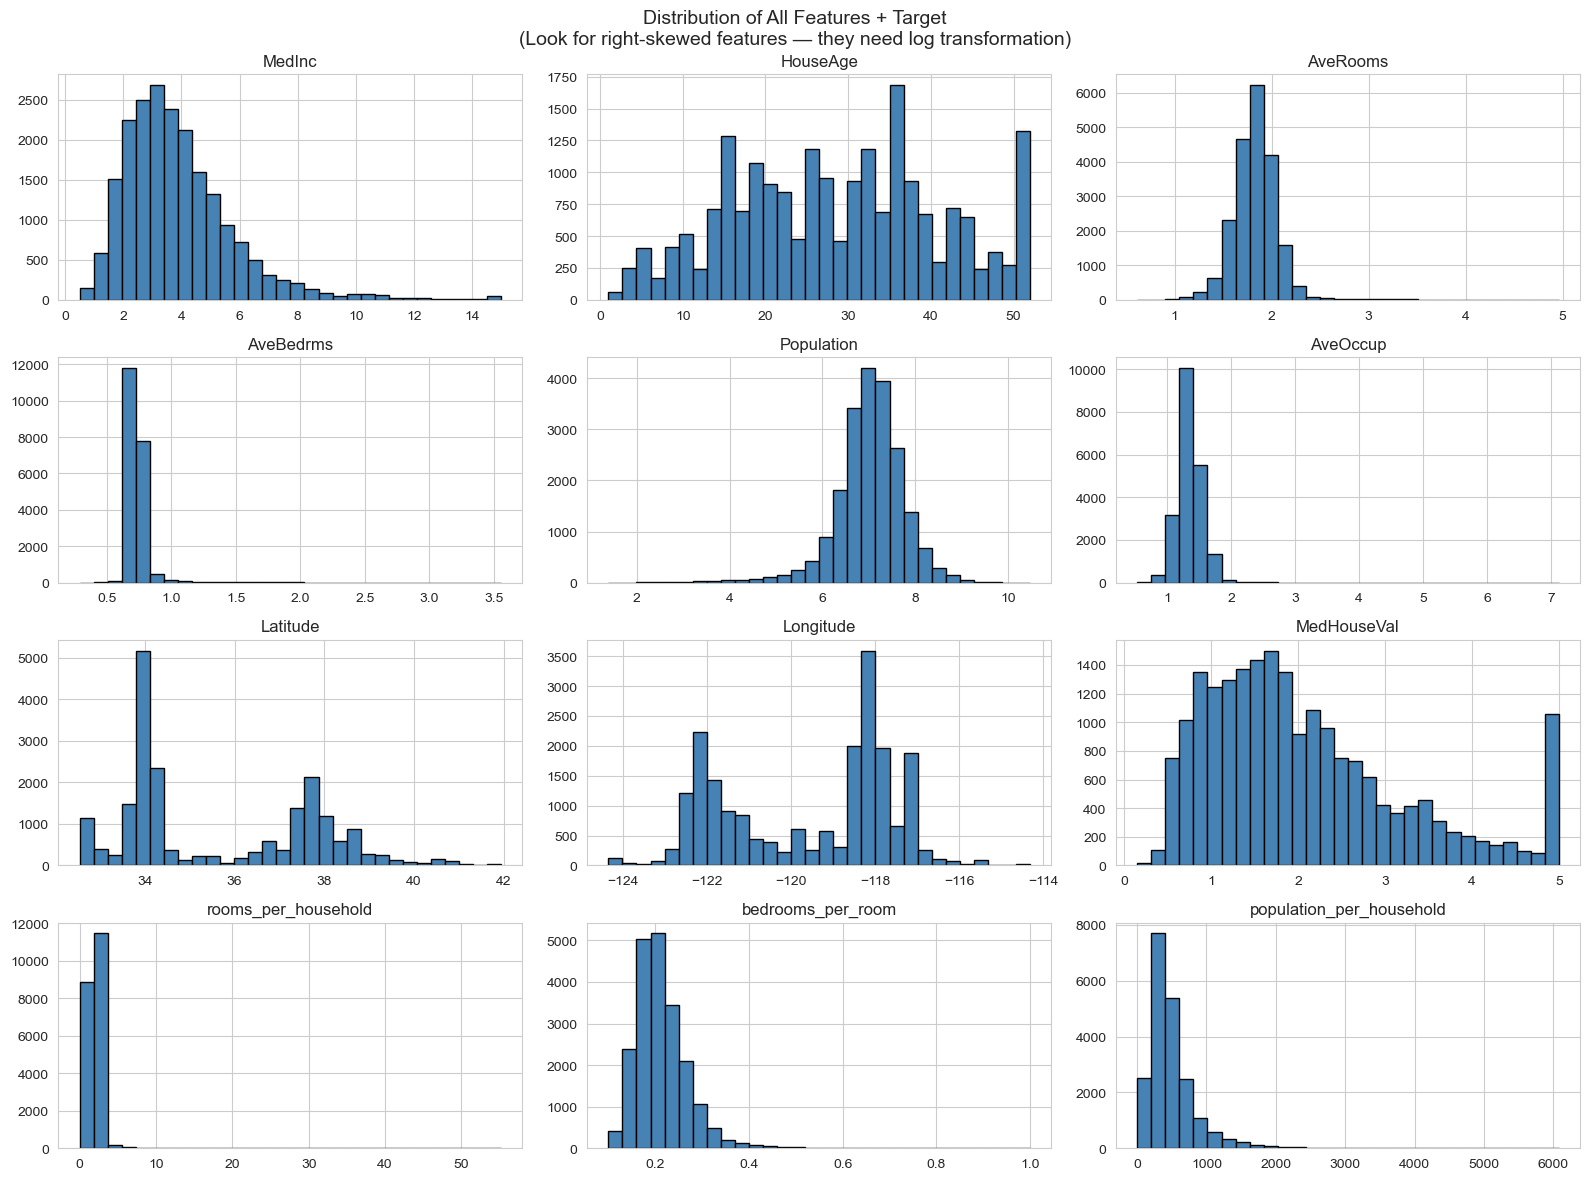

[SAVED] plot_01_feature_distributions.png

[PLOT] Generating Correlation Heatmap...


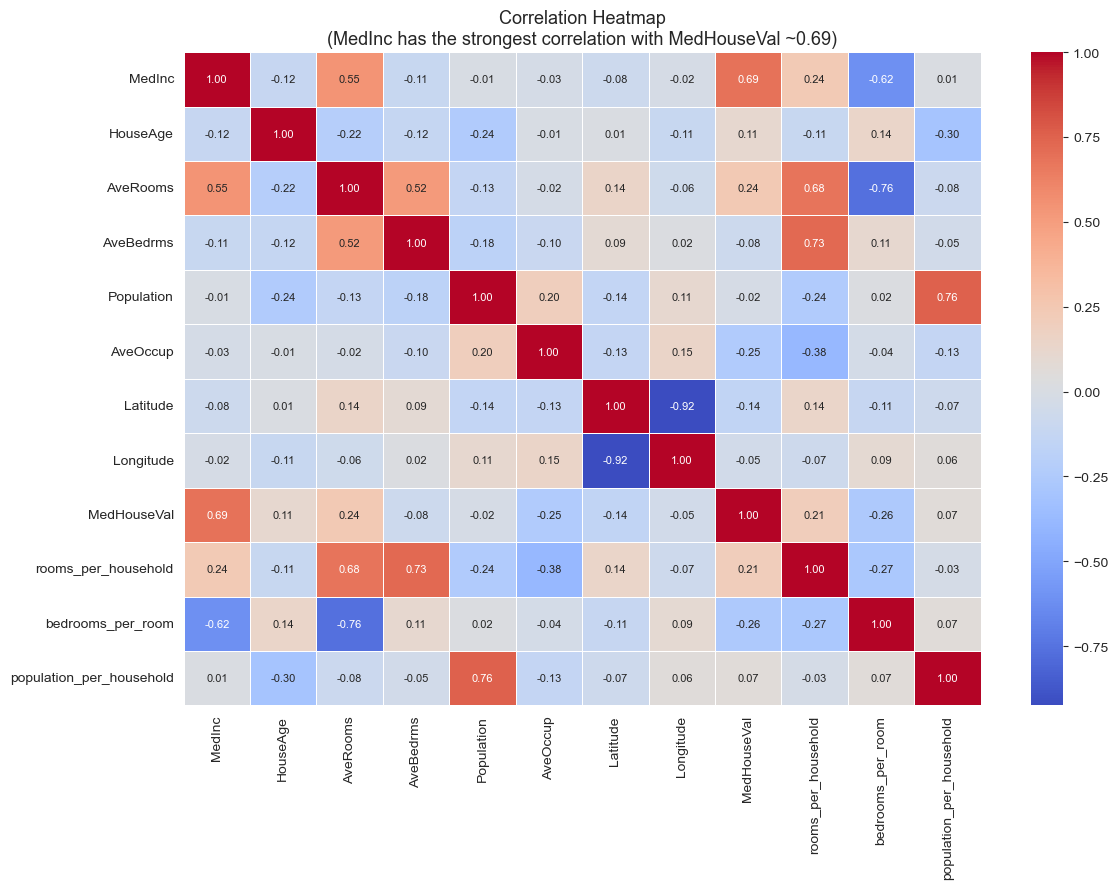

[SAVED] plot_02_correlation_heatmap.png

[INFO] Feature Correlations with MedHouseVal (sorted):
MedInc                      0.688
AveRooms                    0.241
rooms_per_household         0.209
HouseAge                    0.106
population_per_household    0.066
Population                 -0.021
Longitude                  -0.046
AveBedrms                  -0.079
Latitude                   -0.144
AveOccup                   -0.247
bedrooms_per_room          -0.256

[PLOT] Generating MedInc vs MedHouseVal Scatter...


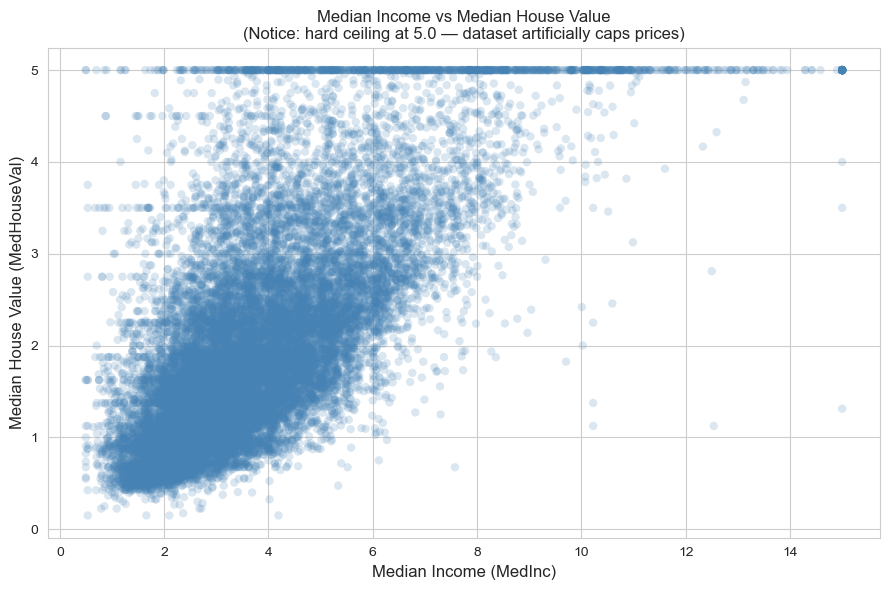

[SAVED] plot_03_medinc_vs_target.png

STEP 3: Log Transformation — Before vs After


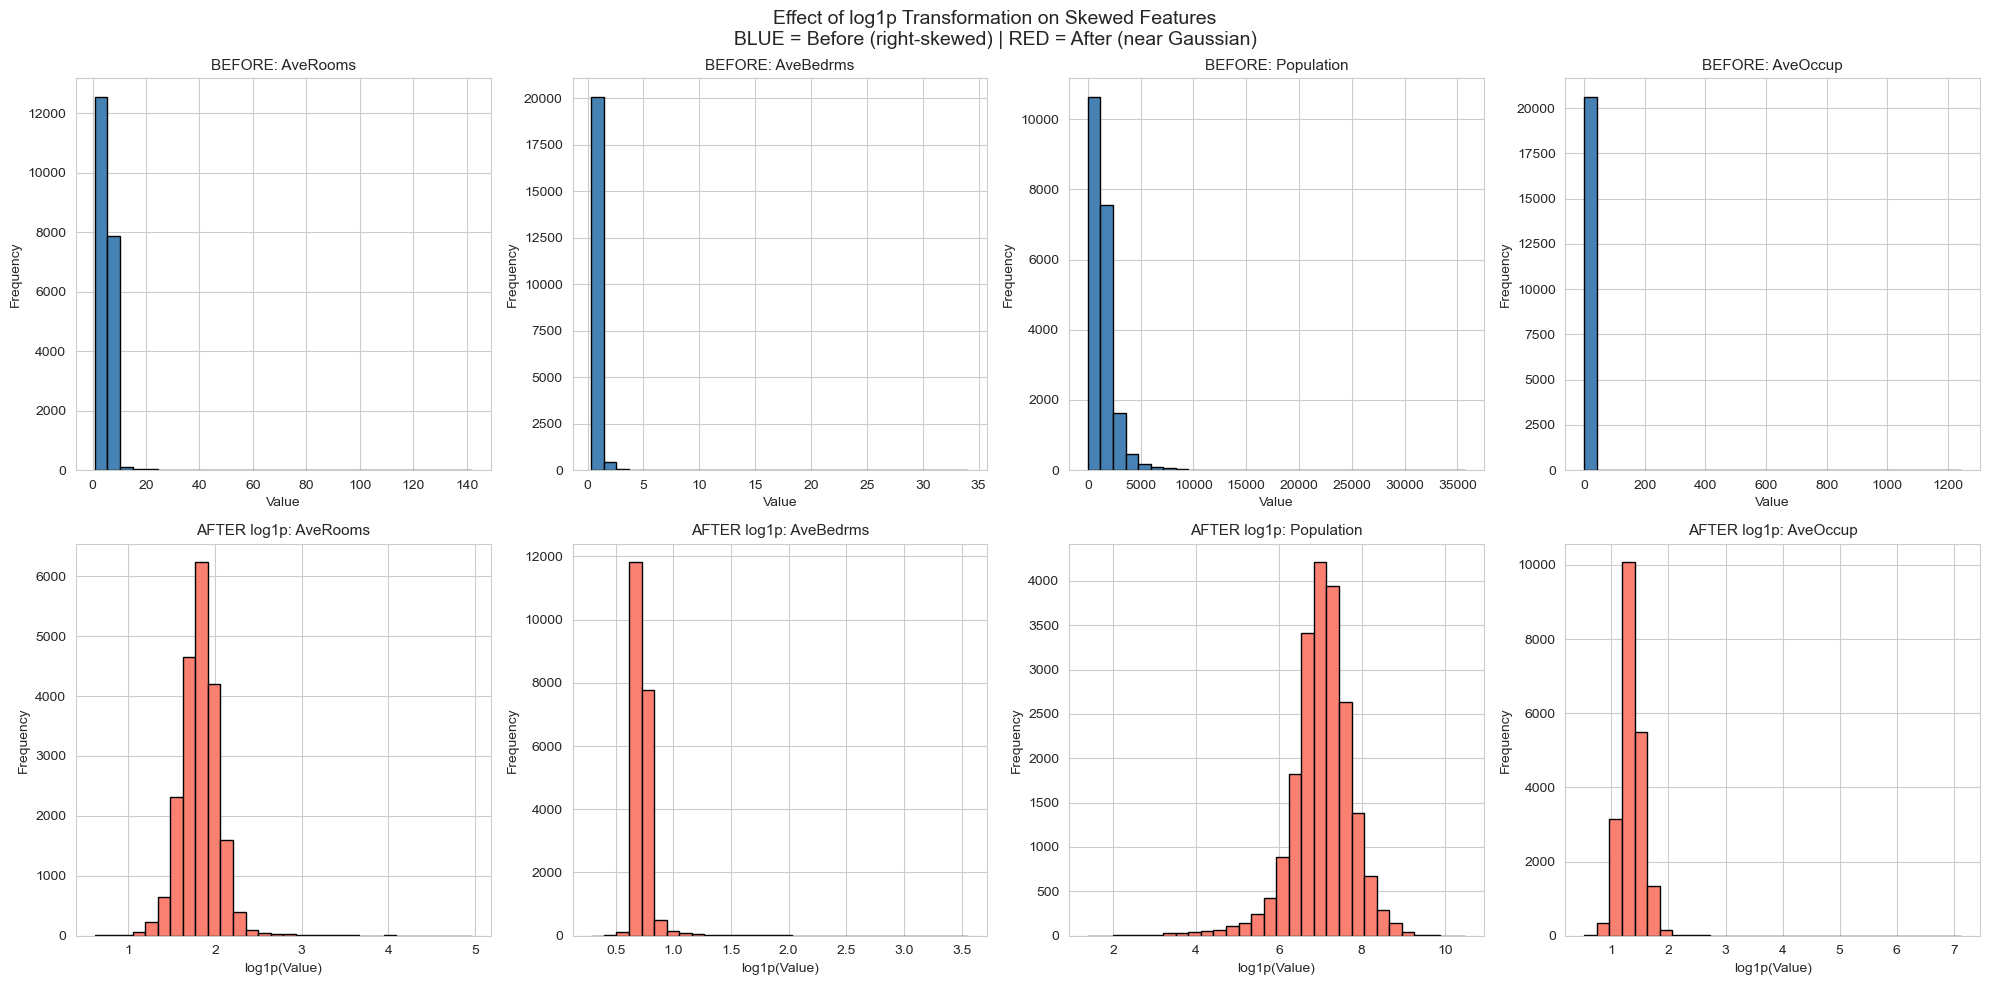

[SAVED] plot_04_log_transform.png

[INFO] Key Insight: After log1p, distributions are much
       more symmetric — neural networks train better on this.

STEP 4: Train/Test Split & Feature Scaling

[INFO] Features (X) shape : (20640, 11)
[INFO] Target  (y) shape  : (20640,)
[INFO] Feature columns    : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household']

[INFO] After Train/Test Split (80/20):
  X_train : (16512, 11)  (model learns from this)
  X_test  : (4128, 11)  (locked away until final eval)
  y_train : (16512,)
  y_test  : (4128,)

[INFO] First 3 Features BEFORE Scaling (X_train):
             Mean      Std
MedInc     3.8808   1.9043
HouseAge  28.6083  12.6025
AveRooms   1.8301   0.2316

[INFO] First 3 Features AFTER Scaling (X_train):
          Mean  Std
MedInc    -0.0  1.0
HouseAge  -0.0  1.0
AveRooms  -0.0  1.0

[CHECK] Mean ≈ 0.0 and Std ≈ 1.0 confirms scaling 

C:\Users\Shailesh\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)


STEP 6: Training the Model

[INFO] Training Configuration:
  Epochs (max)      : 200 (EarlyStopping may halt earlier)
  Batch size        : 32  (update weights every 32 samples)
  Validation split  : 20% of training data
  Early stop on     : val_loss (patience=10)

[TRAINING STARTED]
------------------------------------------------------------
Epoch 1/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.3338 - mae: 0.8086 - val_loss: 0.6368 - val_mae: 0.5237
Epoch 2/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6621 - mae: 0.5578 - val_loss: 0.4998 - val_mae: 0.4654
Epoch 3/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5476 - mae: 0.5052 - val_loss: 0.4727 - val_mae: 0.4481
Epoch 4/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5020 - mae: 0.4805 - val_loss: 0.4539 - val_mae: 0.4425
Epoch 5/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4702 - mae: 0.4645 - val_loss: 0.4524 - val_mae: 0.4459
Epoch 6/200
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

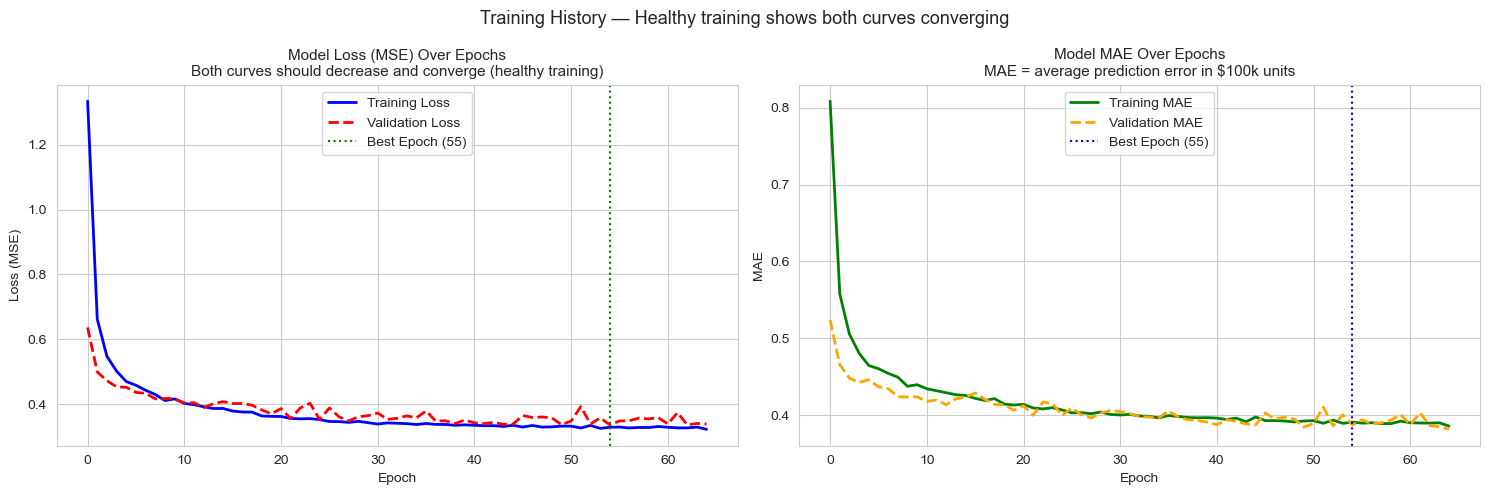

[SAVED] plot_05_training_history.png

STEP 7: Model Evaluation on Test Set

[RESULTS] Test Set Metrics:
  MSE  : 0.3158  (mean squared error, lower = better)
  MAE  : 0.3722  (avg error = ~$37k per house)
  R²   : 0.7730  (model explains 77.3% of price variance)

[INTERPRETATION] Good model performance

[INFO] Residuals Summary:
  Mean : 0.0775  (close to 0 = unbiased)
  Std  : 0.5399
  Min  : -2.6909
  Max  : 4.1930


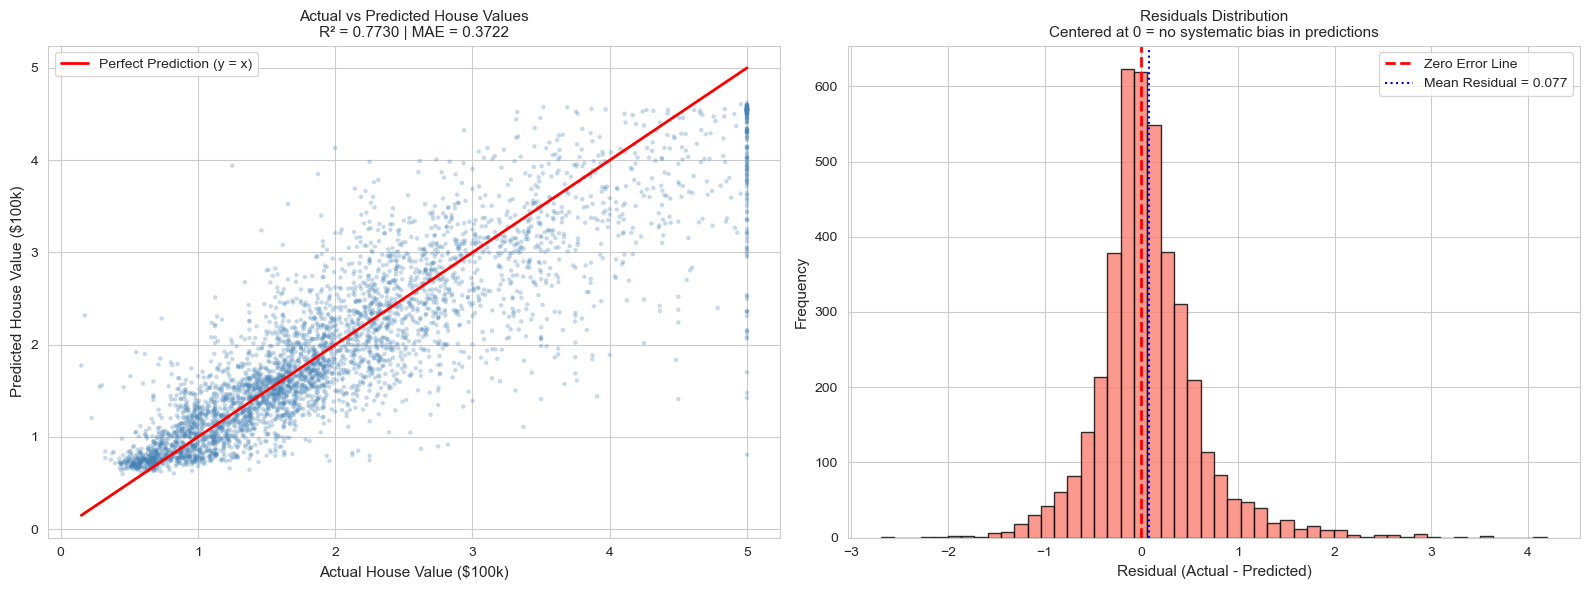

[SAVED] plot_06_evaluation.png

STEP 8: Saving Model Artifacts

[SAVED] house_price_model.keras
        Contains: architecture, weights, optimizer state
[SAVED] scaler.pkl
        Contains: mean and std of each training feature

[IMPORTANT] Always deploy scaler.pkl alongside the model.
            Without it, predictions on raw data will be wrong.

STEP 9: Load Artifacts & Demo Prediction

[LOADED] house_price_model.keras
[LOADED] scaler.pkl

[DEMO] Prediction on First Test Sample:
  Predicted House Value : $70.7k
  Actual House Value    : $47.7k
  Absolute Error        : $23.0k

FINAL SUMMARY
  Dataset       : California Housing (20640 samples)
  Features      : 11 (8 original + 3 engineered)
  Architecture  : Dense(64) → Dense(32) → Dense(16) → Dense(1)
  Regularization: Dropout(0.3) + L2(0.001) + EarlyStopping
  Test MSE      : 0.3158
  Test MAE      : 0.3722  (~$37k avg error)
  Test R²       : 0.7730  (77.3% variance explained)

  Plots saved   : plot_01 through plot_06 (.png)
  M

In [1]:
# ============================================================
# HOUSE PRICE PREDICTION USING TENSORFLOW
# ============================================================
# WHAT YOU ARE LEARNING IN THIS PROJECT:
#   - Data Loading & Exploration        (Step 1)
#   - Exploratory Data Analysis (EDA)   (Step 2)
#   - Feature Engineering               (Step 3)
#   - Train/Test Split & Scaling        (Step 4)
#   - Building a Neural Network         (Step 5)
#   - Training & Visualizing History    (Step 6)
#   - Model Evaluation & Metrics        (Step 7)
#   - Regularization & Early Stopping   (Step 8)
#   - Saving & Loading Model Artifacts  (Step 9)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Set consistent plot style across all visualizations
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100


# ============================================================
# STEP 1 — LOAD DATA & FEATURE ENGINEERING
# ============================================================
# WHAT YOU ARE LEARNING:
#   - How to load a real-world dataset from sklearn
#   - How to create new features from existing ones
#     (called "interaction features") to give the model
#     richer information than raw columns alone
#   - Why log1p() is used: skewed features (long right tails)
#     confuse neural networks. log(x+1) compresses the tail
#     into a more Gaussian shape. We use log1p (not log)
#     because log(0) is undefined — log1p(0) = 0, safe.
# ============================================================

def load_and_engineer_features():
    """
    Load California Housing dataset and return an enriched DataFrame.

    Feature Engineering performed:
      1. Interaction features — ratios that are more meaningful
         than raw counts (e.g. rooms per household, not total rooms)
      2. Log transformation — compresses skewed distributions
         so the neural network trains more stably
    """

    print("\n" + "=" * 60)
    print("STEP 1: Loading Data & Feature Engineering")
    print("=" * 60)

    # --- Load the California Housing dataset ---
    # 20,640 samples, 8 features, 1 target (MedHouseVal)
    # Target is median house value in units of $100,000
    housing = fetch_california_housing()

    df = pd.DataFrame(
        housing.data,
        columns=housing.feature_names
    )
    df["MedHouseVal"] = housing.target

    print("\n[INFO] Raw Dataset Loaded")
    print(f"  Shape          : {df.shape}")
    print(f"  Features       : {list(housing.feature_names)}")
    print(f"  Target         : MedHouseVal (median house value x $100k)")
    print(f"  Missing Values : {df.isnull().sum().sum()}")

    print("\n[INFO] Basic Statistics:")
    print(df.describe().T.round(2).to_string())

    # --------------------------------------------------------
    # INTERACTION FEATURES
    # WHY: AveRooms alone doesn't tell you much. Rooms per
    # household is far more informative about living density.
    # Dividing by AveOccup (average occupants) normalizes by
    # household size, giving meaningful ratios.
    # --------------------------------------------------------
    df["rooms_per_household"] = df["AveRooms"] / df["AveOccup"]
    df["bedrooms_per_room"] = df["AveBedrms"] / df["AveRooms"]
    df["population_per_household"] = df["Population"] / df["AveOccup"]

    print("\n[INFO] Interaction Features Added:")
    print("  rooms_per_household      = AveRooms / AveOccup")
    print("  bedrooms_per_room        = AveBedrms / AveRooms")
    print("  population_per_household = Population / AveOccup")

    # --------------------------------------------------------
    # LOG TRANSFORMATION
    # WHY: These four columns have heavy right skew (verified
    # in EDA). Skewed features cause unstable gradients during
    # backpropagation. log1p brings them closer to Gaussian.
    # --------------------------------------------------------
    skewed_cols = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

    for col in skewed_cols:
        df[col] = np.log1p(df[col])

    print(f"\n[INFO] Log1p Transformation Applied to: {skewed_cols}")
    print(f"[INFO] Final Dataset Shape: {df.shape}")

    return df


# ============================================================
# STEP 2 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# WHAT YOU ARE LEARNING:
#   - How to visually understand your data before modeling
#   - Histogram: reveals the distribution shape of each feature
#   - Correlation heatmap: shows which features are most
#     related to the target (MedHouseVal)
#   - Scatter plot: reveals the relationship between the
#     strongest predictor (MedInc) and the target
#   - Observation: the target is capped at 5.0 ($500k) —
#     this artificial ceiling will affect model predictions
# ============================================================

def plot_eda(df):
    """
    Visualize distributions, correlations, and key relationships.

    Produces 3 plots:
      1. Histogram grid of all features + target
      2. Correlation heatmap
      3. Scatter: MedInc vs MedHouseVal
    """

    print("\n" + "=" * 60)
    print("STEP 2: Exploratory Data Analysis (EDA)")
    print("=" * 60)

    # --------------------------------------------------------
    # PLOT 1: Histogram Grid
    # PURPOSE: See the distribution shape of every feature.
    # Look for: skew, outliers, unusual spikes
    # --------------------------------------------------------
    print("\n[PLOT] Generating Feature Distributions...")
    df.hist(figsize=(16, 12), bins=30, edgecolor="black", color="steelblue")
    plt.suptitle(
        "Distribution of All Features + Target\n"
        "(Look for right-skewed features — they need log transformation)",
        fontsize=14
    )
    plt.tight_layout()
    plt.savefig("plot_01_feature_distributions.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_01_feature_distributions.png")

    # --------------------------------------------------------
    # PLOT 2: Correlation Heatmap
    # PURPOSE: Find which features correlate most strongly
    # with MedHouseVal. Strong correlation = useful feature.
    # KEY INSIGHT: MedInc has the highest correlation (~0.69)
    # --------------------------------------------------------
    print("\n[PLOT] Generating Correlation Heatmap...")
    plt.figure(figsize=(12, 9))
    corr = df.corr()
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        linewidths=0.5,
        annot_kws={"size": 8}
    )
    plt.title(
        "Correlation Heatmap\n"
        "(MedInc has the strongest correlation with MedHouseVal ~0.69)",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig("plot_02_correlation_heatmap.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_02_correlation_heatmap.png")

    # Print top correlations with target for quick reading
    print("\n[INFO] Feature Correlations with MedHouseVal (sorted):")
    target_corr = corr["MedHouseVal"].drop("MedHouseVal").sort_values(
        ascending=False
    )
    print(target_corr.round(3).to_string())

    # --------------------------------------------------------
    # PLOT 3: MedInc vs MedHouseVal Scatter
    # PURPOSE: Visualize the strongest predictor vs target.
    # alpha=0.2 handles overplotting (20k+ points overlap).
    # NOTICE: Hard ceiling at MedHouseVal = 5.0 — this is an
    # artificial cap in the dataset, not real data.
    # --------------------------------------------------------
    print("\n[PLOT] Generating MedInc vs MedHouseVal Scatter...")
    plt.figure(figsize=(9, 6))
    plt.scatter(
        df["MedInc"],
        df["MedHouseVal"],
        alpha=0.2,
        color="steelblue",
        edgecolors="none"
    )
    plt.xlabel("Median Income (MedInc)", fontsize=12)
    plt.ylabel("Median House Value (MedHouseVal)", fontsize=12)
    plt.title(
        "Median Income vs Median House Value\n"
        "(Notice: hard ceiling at 5.0 — dataset artificially caps prices)",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig("plot_03_medinc_vs_target.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_03_medinc_vs_target.png")


# ============================================================
# STEP 3 — LOG TRANSFORM VISUALIZATION
# ============================================================
# WHAT YOU ARE LEARNING:
#   - The visual effect of log1p on skewed distributions
#   - BEFORE: long right tail, model sees extreme values
#   - AFTER:  near bell-shaped, gradients flow more cleanly
#   - This is a core preprocessing technique in real projects
# ============================================================

def plot_log_transform_effect():
    """
    Show before/after histograms of skewed feature transformations.
    This runs on a fresh load to show the raw (untransformed) state.
    """

    print("\n" + "=" * 60)
    print("STEP 3: Log Transformation — Before vs After")
    print("=" * 60)

    housing = fetch_california_housing()
    df_raw = pd.DataFrame(housing.data, columns=housing.feature_names)

    skewed_cols = ["AveRooms", "AveBedrms", "Population", "AveOccup"]

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))

    for i, col in enumerate(skewed_cols):
        # BEFORE — raw skewed distribution
        axes[0, i].hist(
            df_raw[col], bins=30,
            color="steelblue", edgecolor="black"
        )
        axes[0, i].set_title(f"BEFORE: {col}", fontsize=11)
        axes[0, i].set_xlabel("Value")
        axes[0, i].set_ylabel("Frequency")

        # AFTER — log1p transformed
        axes[1, i].hist(
            np.log1p(df_raw[col]), bins=30,
            color="salmon", edgecolor="black"
        )
        axes[1, i].set_title(f"AFTER log1p: {col}", fontsize=11)
        axes[1, i].set_xlabel("log1p(Value)")
        axes[1, i].set_ylabel("Frequency")

    plt.suptitle(
        "Effect of log1p Transformation on Skewed Features\n"
        "BLUE = Before (right-skewed) | RED = After (near Gaussian)",
        fontsize=14
    )
    plt.tight_layout()
    plt.savefig("plot_04_log_transform.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_04_log_transform.png")
    print("\n[INFO] Key Insight: After log1p, distributions are much")
    print("       more symmetric — neural networks train better on this.")


# ============================================================
# STEP 4 — TRAIN/TEST SPLIT & FEATURE SCALING
# ============================================================
# WHAT YOU ARE LEARNING:
#   - WHY split: You need unseen data to honestly evaluate
#     your model. Never evaluate on training data — it lies.
#   - 80/20 split: 80% for training, 20% held out for testing
#   - StandardScaler: transforms features to mean=0, std=1
#   - CRITICAL RULE: fit scaler on TRAIN only, then apply to
#     both. Fitting on full data = data leakage (model sneaks
#     a peek at test statistics = falsely good results)
#   - Why StandardScaler over MinMaxScaler: MinMaxScaler is
#     sensitive to outliers. One extreme value squashes all
#     others into a tiny range. StandardScaler uses mean/std
#     and is more robust to the outliers we saw in EDA.
# ============================================================

def split_and_scale(df):
    """
    Split data into train/test sets and apply StandardScaler.

    RULE: Scaler is fit ONLY on training data, then used to
    transform both train and test — preventing data leakage.

    Returns:
        X_train_scaled, X_test_scaled, y_train, y_test, scaler
    """

    print("\n" + "=" * 60)
    print("STEP 4: Train/Test Split & Feature Scaling")
    print("=" * 60)

    # Separate features (X) from target (y)
    X = df.drop("MedHouseVal", axis=1)
    y = df["MedHouseVal"]

    print(f"\n[INFO] Features (X) shape : {X.shape}")
    print(f"[INFO] Target  (y) shape  : {y.shape}")
    print(f"[INFO] Feature columns    : {list(X.columns)}")

    # 80/20 split with fixed random seed for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42
    )

    print(f"\n[INFO] After Train/Test Split (80/20):")
    print(f"  X_train : {X_train.shape}  (model learns from this)")
    print(f"  X_test  : {X_test.shape}  (locked away until final eval)")
    print(f"  y_train : {y_train.shape}")
    print(f"  y_test  : {y_test.shape}")

    # --- Show stats BEFORE scaling ---
    print("\n[INFO] First 3 Features BEFORE Scaling (X_train):")
    before_stats = pd.DataFrame({
        "Mean": X_train.iloc[:, :3].mean(),
        "Std":  X_train.iloc[:, :3].std()
    })
    print(before_stats.round(4).to_string())

    # --- Fit scaler ONLY on training data ---
    # WHY: If we fit on all data, we leak test set statistics
    # into training. The model would cheat.
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
    X_test_scaled  = scaler.transform(X_test)        # transform only

    # --- Show stats AFTER scaling ---
    print("\n[INFO] First 3 Features AFTER Scaling (X_train):")
    after_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    after_stats = pd.DataFrame({
        "Mean": after_df.iloc[:, :3].mean(),
        "Std":  after_df.iloc[:, :3].std()
    })
    print(after_stats.round(4).to_string())
    print("\n[CHECK] Mean ≈ 0.0 and Std ≈ 1.0 confirms scaling worked.")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


# ============================================================
# STEP 5 — BUILD THE NEURAL NETWORK
# ============================================================
# WHAT YOU ARE LEARNING:
#   - Sequential model: layers stacked one after another
#   - Dense layer: every neuron connects to every neuron
#     in the next layer (fully connected)
#   - ReLU activation: max(0, x) — introduces non-linearity
#     so the network can learn complex patterns, not just lines
#     Also avoids vanishing gradients (unlike sigmoid/tanh)
#   - Output layer has NO activation — we predict a raw
#     continuous number, not a probability (0 to 1)
#   - Loss = MSE: penalizes large errors heavily (they're squared)
#   - Metric = MAE: easier to interpret — "off by X house units"
#   - Optimizer = Adam: adapts learning rate per parameter,
#     almost always the best default for regression
#   - Dropout: randomly disables neurons during training to
#     prevent overfitting (forces redundant learning)
#   - L2 Regularization: penalizes large weights to keep
#     the model generalized
# ============================================================

def build_model(n_features):
    """
    Build and compile the neural network with regularization.

    Architecture:
        Input(n_features)
        → Dense(64, relu) + Dropout(0.3) + L2
        → Dense(32, relu) + Dropout(0.3) + L2
        → Dense(16, relu)
        → Dense(1)  ← single output, no activation (regression)

    Returns:
        Compiled Keras Sequential model
    """

    print("\n" + "=" * 60)
    print("STEP 5: Building Neural Network")
    print("=" * 60)

    model = Sequential([

        # Layer 1: 64 neurons, ReLU, L2 regularization
        # input_shape tells Keras the number of features coming in
        Dense(
            64,
            activation="relu",
            kernel_regularizer=l2(0.001),
            input_shape=(n_features,)
        ),
        # Dropout: randomly disable 30% of neurons each batch
        # WHY: forces other neurons to compensate → less overfitting
        Dropout(0.3),

        # Layer 2: 32 neurons — network narrows (learns abstractions)
        Dense(
            32,
            activation="relu",
            kernel_regularizer=l2(0.001)
        ),
        Dropout(0.3),

        # Layer 3: 16 neurons — deeper abstraction
        Dense(16, activation="relu"),

        # Output: 1 neuron, no activation
        # WHY no activation: sigmoid would squash to [0,1],
        # softmax is for classification. We want raw real values.
        Dense(1)

    ])

    # MSE loss for regression (penalizes large errors heavily)
    # MAE metric for interpretability (in same units as target)
    # Adam optimizer adapts learning rate automatically
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )

    print(f"\n[INFO] Model built for {n_features} input features")
    print("\n[INFO] Model Architecture:")
    model.summary()

    return model


# ============================================================
# STEP 6 — TRAIN THE MODEL & VISUALIZE HISTORY
# ============================================================
# WHAT YOU ARE LEARNING:
#   - EarlyStopping: monitors val_loss every epoch. If it
#     doesn't improve for `patience` epochs, training stops.
#     restore_best_weights=True rolls back to the best epoch
#     (without this, you'd keep the degraded final weights)
#   - validation_split=0.2: Keras holds the last 20% of
#     training data to track val_loss after each epoch
#   - Training curves: plotting loss and MAE over epochs
#     reveals whether your model is healthy, overfitting,
#     or underfitting
#   - Healthy: both train and val loss decrease together
#   - Overfitting: train loss drops, val loss rises
#   - Underfitting: both losses stay high and flat
# ============================================================

def train_model(model, X_train_scaled, y_train):
    """
    Train the model with early stopping and plot training curves.

    Returns:
        history object (contains loss/mae per epoch)
    """

    print("\n" + "=" * 60)
    print("STEP 6: Training the Model")
    print("=" * 60)

    # EarlyStopping: stop when val_loss doesn't improve for 10 epochs
    # restore_best_weights: roll back to the epoch with lowest val_loss
    # WHY: without this, training might stop at epoch 80 but keep
    #      the weights from epoch 80 (which were already getting worse)
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    print("\n[INFO] Training Configuration:")
    print("  Epochs (max)      : 200 (EarlyStopping may halt earlier)")
    print("  Batch size        : 32  (update weights every 32 samples)")
    print("  Validation split  : 20% of training data")
    print("  Early stop on     : val_loss (patience=10)")
    print("\n[TRAINING STARTED]")
    print("-" * 60)

    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=200,
        batch_size=32,
        validation_split=0.20,
        callbacks=[early_stopping],
        verbose=1
    )

    actual_epochs = len(history.history["loss"])
    best_epoch = np.argmin(history.history["val_loss"]) + 1

    print("\n[TRAINING COMPLETE]")
    print(f"  Trained for      : {actual_epochs} epochs")
    print(f"  Best epoch       : {best_epoch} (lowest val_loss)")
    print(f"  Final train loss : {history.history['loss'][-1]:.4f}")
    print(f"  Final val loss   : {history.history['val_loss'][-1]:.4f}")
    print(f"  Final train MAE  : {history.history['mae'][-1]:.4f}")
    print(f"  Final val MAE    : {history.history['val_mae'][-1]:.4f}")

    # --------------------------------------------------------
    # PLOT: Training Curves
    # PURPOSE: Visually confirm training behavior.
    # A good model shows both curves declining and converging.
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # --- Loss (MSE) ---
    axes[0].plot(
        history.history["loss"],
        label="Training Loss",
        color="blue",
        linewidth=2
    )
    axes[0].plot(
        history.history["val_loss"],
        label="Validation Loss",
        color="red",
        linewidth=2,
        linestyle="--"
    )
    axes[0].axvline(
        x=best_epoch - 1,
        color="green",
        linestyle=":",
        linewidth=1.5,
        label=f"Best Epoch ({best_epoch})"
    )
    axes[0].set_title(
        "Model Loss (MSE) Over Epochs\n"
        "Both curves should decrease and converge (healthy training)",
        fontsize=11
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (MSE)")
    axes[0].legend()
    axes[0].grid(True)

    # --- MAE ---
    axes[1].plot(
        history.history["mae"],
        label="Training MAE",
        color="green",
        linewidth=2
    )
    axes[1].plot(
        history.history["val_mae"],
        label="Validation MAE",
        color="orange",
        linewidth=2,
        linestyle="--"
    )
    axes[1].axvline(
        x=best_epoch - 1,
        color="blue",
        linestyle=":",
        linewidth=1.5,
        label=f"Best Epoch ({best_epoch})"
    )
    axes[1].set_title(
        "Model MAE Over Epochs\n"
        "MAE = average prediction error in $100k units",
        fontsize=11
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(
        "Training History — Healthy training shows both curves converging",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig("plot_05_training_history.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_05_training_history.png")

    return history


# ============================================================
# STEP 7 — EVALUATE THE MODEL
# ============================================================
# WHAT YOU ARE LEARNING:
#   - MSE (Mean Squared Error): average of squared errors.
#     Penalizes large errors heavily. Hard to interpret directly
#     because units are squared.
#   - MAE (Mean Absolute Error): average of absolute errors.
#     Interpretable — "on average, predictions are off by X"
#     (here, X is in units of $100k)
#   - R² Score: how much of the target variance your model
#     explains. 1.0 = perfect, 0.0 = no better than mean,
#     negative = worse than just predicting the mean.
#   - Actual vs Predicted scatter: points near the diagonal
#     = accurate model. Horizontal band at y=5.0 is the
#     dataset's artificial price cap showing up in actuals.
#   - Residuals plot: errors should be randomly scattered
#     around zero. A pattern in residuals = model bias.
# ============================================================

def evaluate_model(model, X_test_scaled, y_test):
    """
    Evaluate model on held-out test set and visualize results.

    Plots:
      1. Actual vs Predicted scatter
      2. Residuals distribution

    Returns:
        (test_mse, test_mae, test_r2)
    """

    print("\n" + "=" * 60)
    print("STEP 7: Model Evaluation on Test Set")
    print("=" * 60)

    # Evaluate — model has never seen X_test_scaled before
    test_mse, test_mae = model.evaluate(
        X_test_scaled, y_test,
        verbose=0
    )

    # Generate predictions
    y_pred = model.predict(X_test_scaled, verbose=0).flatten()

    # R² — percentage of variance in target that model explains
    test_r2 = r2_score(y_test, y_pred)

    print("\n[RESULTS] Test Set Metrics:")
    print(f"  MSE  : {test_mse:.4f}  (mean squared error, lower = better)")
    print(f"  MAE  : {test_mae:.4f}  (avg error = ~${test_mae * 100:.0f}k per house)")
    print(f"  R²   : {test_r2:.4f}  (model explains {test_r2*100:.1f}% of price variance)")

    # Interpret R²
    if test_r2 >= 0.85:
        interpretation = "Excellent model performance"
    elif test_r2 >= 0.75:
        interpretation = "Good model performance"
    elif test_r2 >= 0.60:
        interpretation = "Moderate model performance"
    else:
        interpretation = "Model needs improvement"

    print(f"\n[INTERPRETATION] {interpretation}")

    # --------------------------------------------------------
    # PLOT 1: Actual vs Predicted
    # PURPOSE: Perfect model = all points on the red diagonal.
    # Spread around diagonal shows prediction error.
    # Horizontal band at actual=5.0 is the dataset price cap.
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].scatter(
        y_test, y_pred,
        alpha=0.3,
        color="steelblue",
        edgecolors="none",
        s=10
    )
    # Perfect prediction line: where predicted = actual
    min_val = min(float(y_test.min()), float(y_pred.min()))
    max_val = max(float(y_test.max()), float(y_pred.max()))
    axes[0].plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linewidth=2,
        label="Perfect Prediction (y = x)"
    )
    axes[0].set_xlabel("Actual House Value ($100k)", fontsize=11)
    axes[0].set_ylabel("Predicted House Value ($100k)", fontsize=11)
    axes[0].set_title(
        f"Actual vs Predicted House Values\n"
        f"R² = {test_r2:.4f} | MAE = {test_mae:.4f}",
        fontsize=11
    )
    axes[0].legend()
    axes[0].grid(True)

    # --------------------------------------------------------
    # PLOT 2: Residuals Distribution
    # PURPOSE: residual = actual - predicted. A good model
    # has residuals centered at 0 (no systematic bias).
    # Non-zero mean = model consistently over/underpredicts.
    # --------------------------------------------------------
    residuals = y_test.values - y_pred

    axes[1].hist(
        residuals,
        bins=50,
        color="salmon",
        edgecolor="black",
        alpha=0.8
    )
    axes[1].axvline(
        x=0, color="red",
        linewidth=2, linestyle="--",
        label="Zero Error Line"
    )
    axes[1].axvline(
        x=residuals.mean(),
        color="blue",
        linewidth=1.5,
        linestyle=":",
        label=f"Mean Residual = {residuals.mean():.3f}"
    )
    axes[1].set_xlabel("Residual (Actual - Predicted)", fontsize=11)
    axes[1].set_ylabel("Frequency", fontsize=11)
    axes[1].set_title(
        "Residuals Distribution\n"
        "Centered at 0 = no systematic bias in predictions",
        fontsize=11
    )
    axes[1].legend()
    axes[1].grid(True)

    print(f"\n[INFO] Residuals Summary:")
    print(f"  Mean : {residuals.mean():.4f}  (close to 0 = unbiased)")
    print(f"  Std  : {residuals.std():.4f}")
    print(f"  Min  : {residuals.min():.4f}")
    print(f"  Max  : {residuals.max():.4f}")

    plt.tight_layout()
    plt.savefig("plot_06_evaluation.png", bbox_inches="tight")
    plt.show()
    print("[SAVED] plot_06_evaluation.png")

    return test_mse, test_mae, test_r2


# ============================================================
# STEP 8 — SAVE & LOAD ARTIFACTS
# ============================================================
# WHAT YOU ARE LEARNING:
#   - WHY save the model: so you don't retrain every time.
#     Training is expensive — save once, load many times.
#   - WHY save the scaler: the model learned from scaled data
#     (mean=0, std=1). In production, new inputs must be
#     transformed using the SAME scaler that was fit on
#     training data. A new scaler would produce different
#     numbers → completely wrong predictions.
#   - joblib: efficient serialization for sklearn objects
#   - model.save(.keras): TensorFlow's native format, saves
#     architecture + weights + optimizer state together
# ============================================================

def save_artifacts(model, scaler):
    """
    Save trained model and scaler to disk.

    WHY BOTH:
      Model alone is useless if raw input isn't scaled the
      same way as training data. The scaler IS part of the
      production pipeline — always ship them together.
    """

    print("\n" + "=" * 60)
    print("STEP 8: Saving Model Artifacts")
    print("=" * 60)

    # Save TensorFlow model (architecture + weights + optimizer)
    model.save("house_price_model.keras")
    print("\n[SAVED] house_price_model.keras")
    print("        Contains: architecture, weights, optimizer state")

    # Save scaler using joblib (efficient for sklearn objects)
    joblib.dump(scaler, "scaler.pkl")
    print("[SAVED] scaler.pkl")
    print("        Contains: mean and std of each training feature")
    print("\n[IMPORTANT] Always deploy scaler.pkl alongside the model.")
    print("            Without it, predictions on raw data will be wrong.")


# ============================================================
# STEP 9 — LOAD & DEMO INFERENCE
# ============================================================
# WHAT YOU ARE LEARNING:
#   - Loading saved artifacts simulates a production environment
#   - The pipeline for a new prediction is ALWAYS:
#       raw input → same scaler transform → model.predict()
#   - reshape(1, -1): model.predict() expects a 2D array
#     (batch_size, n_features). A single sample is shape (n,)
#     so we reshape to (1, n) to represent a batch of 1.
# ============================================================

def load_and_predict(X_test_scaled, y_test):
    """
    Load saved artifacts and demonstrate inference on one sample.

    This simulates what a production API call would do:
      1. Receive raw input
      2. Scale with the saved scaler
      3. Feed to model and return prediction
    """

    print("\n" + "=" * 60)
    print("STEP 9: Load Artifacts & Demo Prediction")
    print("=" * 60)

    # Load the saved model and scaler back from disk
    loaded_model  = load_model("house_price_model.keras")
    loaded_scaler = joblib.load("scaler.pkl")

    print("\n[LOADED] house_price_model.keras")
    print("[LOADED] scaler.pkl")

    # Take the first test sample as a demo input
    # reshape(1, -1) converts shape (n,) → (1, n) for predict()
    sample = X_test_scaled[0].reshape(1, -1)

    prediction = loaded_model.predict(sample, verbose=0)[0][0]
    actual     = float(y_test.iloc[0])

    print("\n[DEMO] Prediction on First Test Sample:")
    print(f"  Predicted House Value : ${prediction * 100:.1f}k")
    print(f"  Actual House Value    : ${actual * 100:.1f}k")
    print(f"  Absolute Error        : ${abs(prediction - actual) * 100:.1f}k")

    return loaded_model


# ============================================================
# MAIN PIPELINE — Ties everything together
# ============================================================

def main():

    print("\n" + "=" * 60)
    print("  HOUSE PRICE PREDICTION — TENSORFLOW NEURAL NETWORK")
    print("=" * 60)
    print("  This pipeline covers:")
    print("  Data Loading → EDA → Feature Engineering →")
    print("  Scaling → Model Build → Train → Evaluate → Save")

    # STEP 1: Load raw data and engineer features
    df = load_and_engineer_features()

    # STEP 2: EDA — understand data visually before modeling
    plot_eda(df)

    # STEP 3: Visualize the effect of log transformation
    plot_log_transform_effect()

    # STEP 4: Split into train/test and scale features
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = split_and_scale(df)

    # STEP 5: Build the neural network
    model = build_model(n_features=X_train_scaled.shape[1])

    # STEP 6: Train with early stopping, plot learning curves
    history = train_model(model, X_train_scaled, y_train)

    # STEP 7: Evaluate on held-out test data
    test_mse, test_mae, test_r2 = evaluate_model(
        model, X_test_scaled, y_test
    )

    # STEP 8: Save model and scaler to disk
    save_artifacts(model, scaler)

    # STEP 9: Load back and run a demo prediction
    load_and_predict(X_test_scaled, y_test)

    # --------------------------------------------------------
    # FINAL SUMMARY
    # --------------------------------------------------------
    print("\n" + "=" * 60)
    print("FINAL SUMMARY")
    print("=" * 60)
    print(f"  Dataset       : California Housing ({df.shape[0]} samples)")
    print(f"  Features      : {X_train_scaled.shape[1]} (8 original + 3 engineered)")
    print(f"  Architecture  : Dense(64) → Dense(32) → Dense(16) → Dense(1)")
    print(f"  Regularization: Dropout(0.3) + L2(0.001) + EarlyStopping")
    print(f"  Test MSE      : {test_mse:.4f}")
    print(f"  Test MAE      : {test_mae:.4f}  (~${test_mae * 100:.0f}k avg error)")
    print(f"  Test R²       : {test_r2:.4f}  ({test_r2 * 100:.1f}% variance explained)")
    print("\n  Plots saved   : plot_01 through plot_06 (.png)")
    print("  Model saved   : house_price_model.keras")
    print("  Scaler saved  : scaler.pkl")
    print("\n[DONE] Pipeline complete.")


# ============================================================
# ENTRY POINT
# ============================================================
# WHY __name__ == "__main__":
#   This guard ensures main() only runs when you execute this
#   script directly (python house_price_prediction.py).
#   If someone imports this file as a module, main() won't
#   auto-execute — they can import the functions individually.
# ============================================================

if __name__ == "__main__":
    main()